# 05 - Threshold Analysis

## Objective
This notebook evaluates different decision thresholds for the champion fee-defaulter risk model.

Rather than using the default 0.50 probability cutoff automatically, this notebook compares multiple thresholds to understand the tradeoff between:

- precision
- recall
- F1-score

This helps determine which threshold is most appropriate for identifying higher-risk students.

In [11]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
project_root = Path("/content/drive/MyDrive/fee-defaulter-prediction")

model_path = project_root / "models" / "best_model.pkl"
X_test_path = project_root / "data" / "processed" / "03_best_X_test.csv"
y_test_path = project_root / "data" / "processed" / "03_best_y_test.csv"

(project_root / "reports").mkdir(parents=True, exist_ok=True)
(project_root / "reports" / "figures").mkdir(parents=True, exist_ok=True)

In [13]:
best_model = joblib.load(model_path)

X_test_best = pd.read_csv(X_test_path)
y_test_best = pd.read_csv(y_test_path).squeeze()

print("X_test shape:", X_test_best.shape)
print("y_test shape:", y_test_best.shape)

X_test shape: (79, 36)
y_test shape: (79,)


In [14]:
y_prob = best_model.predict_proba(X_test_best)[:, 1]

pd.Series(y_prob).describe()

,0
count,79.000000
mean,0.361443
std,0.399277
min,0.000000
25%,0.028333
50%,0.107022
75%,0.848308
max,0.993333


## Threshold Testing Strategy

The model outputs probabilities between 0 and 1.

A student is classified as high risk if the predicted probability is greater than or equal to a chosen threshold.

Lower thresholds usually increase recall but may reduce precision.
Higher thresholds usually increase precision but may reduce recall.

In [15]:
thresholds = np.arange(0.1, 0.91, 0.05)

rows = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    rows.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test_best, y_pred_thresh),
        "precision": precision_score(y_test_best, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_test_best, y_pred_thresh, zero_division=0),
        "f1": f1_score(y_test_best, y_pred_thresh, zero_division=0),
        "predicted_positive_count": int(y_pred_thresh.sum())
    })

threshold_results = pd.DataFrame(rows)
threshold_results

,threshold,accuracy,precision,recall,f1,predicted_positive_count
0,0.10,0.873418,0.756098,1.000000,0.861111,41
1,0.15,0.949367,0.885714,1.000000,0.939394,35
2,0.20,0.974684,0.939394,1.000000,0.968750,33
3,0.25,0.974684,0.939394,1.000000,0.968750,33
4,0.30,0.974684,0.967742,0.967742,0.967742,31
5,0.35,0.962025,0.966667,0.935484,0.950820,30
6,0.40,0.962025,0.966667,0.935484,0.950820,30
7,0.45,0.949367,0.965517,0.903226,0.933333,29
8,0.50,0.949367,0.965517,0.903226,0.933333,29
9,0.55,0.936709,0.964286,0.870968,0.915254,28


In [16]:
threshold_results.sort_values(by="f1", ascending=False)

,threshold,accuracy,precision,recall,f1,predicted_positive_count
2,0.20,0.974684,0.939394,1.000000,0.968750,33
3,0.25,0.974684,0.939394,1.000000,0.968750,33
4,0.30,0.974684,0.967742,0.967742,0.967742,31
6,0.40,0.962025,0.966667,0.935484,0.950820,30
5,0.35,0.962025,0.966667,0.935484,0.950820,30
1,0.15,0.949367,0.885714,1.000000,0.939394,35
7,0.45,0.949367,0.965517,0.903226,0.933333,29
8,0.50,0.949367,0.965517,0.903226,0.933333,29
9,0.55,0.936709,0.964286,0.870968,0.915254,28
10,0.60,0.911392,1.000000,0.774194,0.872727,24


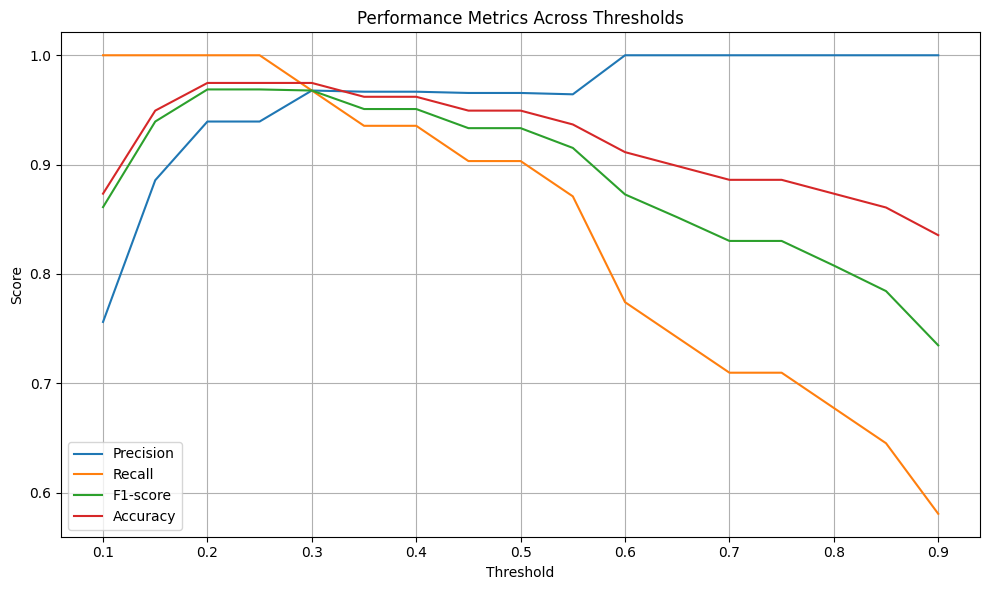

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1-score")
plt.plot(threshold_results["threshold"], threshold_results["accuracy"], label="Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Performance Metrics Across Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / "threshold_metrics_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
best_f1_row = threshold_results.sort_values(by="f1", ascending=False).iloc[0]
best_f1_row

,2
threshold,0.200000
accuracy,0.974684
precision,0.939394
recall,1.000000
f1,0.968750
predicted_positive_count,33.000000


In [19]:
chosen_threshold = best_f1_row["threshold"]

print("Chosen threshold:", chosen_threshold)
print("Accuracy:", round(best_f1_row["accuracy"], 4))
print("Precision:", round(best_f1_row["precision"], 4))
print("Recall:", round(best_f1_row["recall"], 4))
print("F1:", round(best_f1_row["f1"], 4))
print("Predicted positive count:", int(best_f1_row["predicted_positive_count"]))

Chosen threshold: 0.2
Accuracy: 0.9747
Precision: 0.9394
Recall: 1.0
F1: 0.9688
Predicted positive count: 33


In [20]:
candidate_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

candidate_rows = []

for threshold in candidate_thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    candidate_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_best, y_pred_thresh),
        "precision": precision_score(y_test_best, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_test_best, y_pred_thresh, zero_division=0),
        "f1": f1_score(y_test_best, y_pred_thresh, zero_division=0),
        "predicted_positive_count": int(y_pred_thresh.sum())
    })

candidate_results = pd.DataFrame(candidate_rows)
candidate_results

,threshold,accuracy,precision,recall,f1,predicted_positive_count
0,0.3,0.974684,0.967742,0.967742,0.967742,31
1,0.4,0.962025,0.966667,0.935484,0.950820,30
2,0.5,0.949367,0.965517,0.903226,0.933333,29
3,0.6,0.911392,1.000000,0.774194,0.872727,24
4,0.7,0.886076,1.000000,0.709677,0.830189,22


## Decision Perspective

Threshold selection depends on the operational goal of the system.

For this project, recall is important because failing to identify a genuinely high-risk student may reduce the opportunity for early intervention.

However, precision also matters because flagging too many low-risk students may waste institutional attention and resources.

The selected threshold should therefore balance early detection with practical intervention capacity.

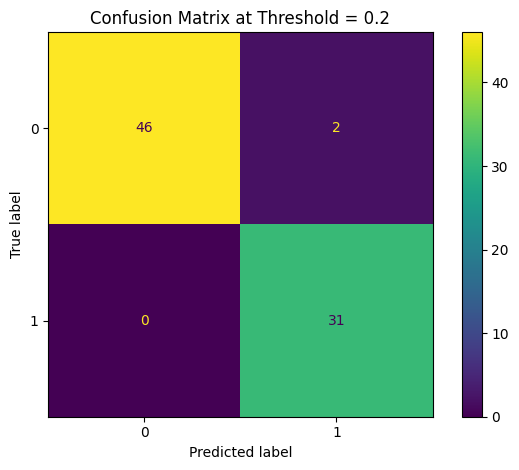

In [21]:
y_pred_chosen = (y_prob >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test_best, y_pred_chosen)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix at Threshold = {chosen_threshold}")
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / f"confusion_matrix_threshold_{chosen_threshold}.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
threshold_results_path = project_root / "reports" / "threshold_results.csv"
threshold_results.to_csv(threshold_results_path, index=False)

print(f"Saved threshold results to: {threshold_results_path}")

Saved threshold results to: /content/drive/MyDrive/fee-defaulter-prediction/reports/threshold_results.csv


In [23]:
chosen_threshold_path = project_root / "reports" / "chosen_threshold.txt"

with open(chosen_threshold_path, "w") as f:
    f.write(str(chosen_threshold))

print(f"Saved chosen threshold to: {chosen_threshold_path}")

Saved chosen threshold to: /content/drive/MyDrive/fee-defaulter-prediction/reports/chosen_threshold.txt


## Notebook 05 Summary

This notebook evaluated multiple probability thresholds for the champion Random Forest model.

The analysis showed that model performance changes depending on the cutoff used to classify students as high risk.

A final threshold was selected based on metric tradeoffs, especially precision, recall, and F1-score, to support practical early-risk identification.

In [24]:
default_05 = threshold_results[threshold_results["threshold"] == 0.5]
default_05

,threshold,accuracy,precision,recall,f1,predicted_positive_count
8,0.5,0.949367,0.965517,0.903226,0.933333,29


## Threshold Interpretation

The threshold analysis showed that the best F1-score was achieved at a cutoff of **0.20** (also matched by 0.25), with:

- Accuracy: 0.9747
- Precision: 0.9394
- Recall: 1.0000
- F1-score: 0.9688

This means the model identified all high-risk students in the test set while maintaining strong precision.

A threshold of **0.30** also performed very well, with slightly fewer flagged students and a more balanced precision-recall tradeoff.

For this project, **0.20** is selected as the primary operational threshold because early intervention favors higher recall. However, **0.30** may be preferable in settings where intervention resources are more limited.